In [1]:
import os ; os.chdir('/home/sebastiaan/phd/repositories/immune_response_detection/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from clustcrdist.constants.distance import TCRDIST_DM
from clustcrdist.constants.base import AALPHABET
from clustcrdist.constants.modules.tcrdist.tcr_distances import TcrDistCalculator
from clustcrdist.encoding import TCRDistEncoder
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr
from itertools import combinations

TCRDIST_DM = TCRDIST_DM ** 2

import seaborn as sns

# Setting up the plot styles
plt.style.use(['seaborn-white', 'seaborn-paper'])
plt.rc('font', family='serif')
sns.set_palette('Set1')
sns.set_context('paper', font_scale=1.3)    # single-column figure

/tmp/ipykernel_1385806/1606806234.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['seaborn-white', 'seaborn-paper'])
/tmp/ipykernel_1385806/1606806234.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['seaborn-white', 'seaborn-paper'])


## **TCRdist distance matrix**

TCRdist distance matrix, visualized in grayscale. The matrix depicts pairwise distances between different amino acids based on the BLOSUM62 substitution matrix, normalized to a range from 0 to 4. The lower triangle of the matrix is annotated with rounded distance values, where higher values (darker shades) indicate greater distances between amino acids, and lower values (lighter shades) represent more similar amino acids. A grayscale legend on the right highlights the exact shades corresponding to values from 0 (white) to 4 (black), providing a clear visual mapping of distance magnitudes.

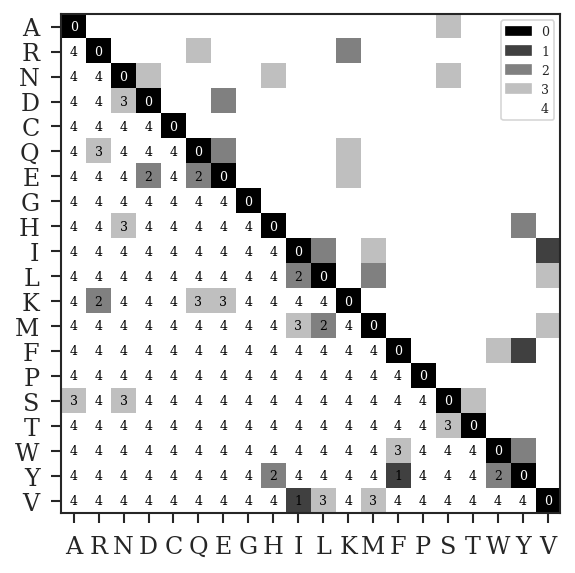

In [84]:
fig, ax = plt.subplots(dpi=150, figsize=(4, 4))

# Display the matrix
im = ax.imshow(TCRDIST_DM, cmap='gray')

# Annotate only the lower triangle (i >= j)
for i in range(TCRDIST_DM.shape[0]):
    for j in range(TCRDIST_DM.shape[1]):
        if i >= j:  # Only annotate the lower triangle
            value = round(TCRDIST_DM[i, j])
            color = 'black' if value != 0 else 'white'
            ax.text(j, i, f"{value}", ha='center', va='center', color=color, fontsize=6)

# Define custom color legend with specific values (0 to 4)
cmap = plt.get_cmap('gray')
norm = plt.Normalize(vmin=0, vmax=4)
grayscale_colors = [cmap(norm(value)) for value in range(5)]

legend_elements = legend_elements = [mpatches.Patch(color=i, label=n) for n, i in enumerate(grayscale_colors)]
# Place the legend in the upper right corner of the plot
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1), fontsize=6, frameon=True)

# Hide the minor ticks
ax.tick_params(which='minor', size=0)
ax.set_xticks(np.arange(len(AALPHABET)))
ax.set_yticks(np.arange(len(AALPHABET)))
ax.set_xticklabels(AALPHABET)
ax.set_yticklabels(AALPHABET)

fig.tight_layout()
plt.show()

fig.savefig('../sne_manuscript/fig/tcrdist_matrix.png', bbox_inches='tight', dpi=500)

In [35]:
pregibon = pd.read_table("../sne_manuscript/data/phil/pregibon_tcrs.tsv")

n = 200

pregibon_alpha = pregibon[['va', 'ja', 'cdr3a']].sample(n)
pregibon_alpha.columns = ["v_call","j_call","junction_aa"]

pregibon_beta = pregibon[['vb', 'jb', 'cdr3b']].sample(n)
pregibon_beta.columns = ["v_call","j_call","junction_aa"]

tdist = TcrDistCalculator("human")

alpha_chains = [tuple(alpha[1]) for alpha in pregibon_alpha.iterrows()]
beta_chains = [tuple(beta[1]) for beta in pregibon_beta.iterrows()]

d_td_a = pdist(X=alpha_chains, metric=tdist.single_chain_distance)
d_td_b = pdist(X=beta_chains, metric=tdist.single_chain_distance)

In [96]:
pregibon_beta

,v_call,j_call,junction_aa
0,TRBV10-3*01,TRBJ2-1*01,CAISESNDGNEQFF
1,TRBV7-6*01,TRBJ2-7*01,CASTLGTSHDYEQYF
2,TRBV10-3*01,TRBJ2-7*01,CAISESLGQDQQYF
3,TRBV10-3*01,TRBJ2-3*01,CAISESRSSGADTQYF
4,TRBV10-3*01,TRBJ2-1*01,CAISESTGLRDEQFF
...,...,...,...
919,TRBV27*01,TRBJ2-7*01,CASSLTAAYEQYF
920,TRBV12-5*01,TRBJ1-1*01,CASGLGTRQFTEAFF
921,TRBV7-3*01,TRBJ2-1*01,CASSFDHRGRDEQFF
922,TRBV2*01,TRBJ1-5*01,CATQHRDIVGEPQHF


In [97]:
dims_a = []
corr_a = []
dims_b = []
corr_b = []
for i in range(1,21,1):
    # alpha chain
    alpha_encoder = TCRDistEncoder(aa_dim=i, chain='a', organism='human', cdr3_col='junction_aa').fit()
    vecs = alpha_encoder.transform(pregibon_alpha)
    d_vec_a = pdist(X=vecs, metric="euclidean")**2
    r = pearsonr(d_td_a, d_vec_a)[0]
    dims_a.append(i)
    corr_a.append(r)
    # beta chain
    beta_encoder = TCRDistEncoder(aa_dim=i, chain='b', organism='human', cdr3_col='junction_aa').fit()
    vecs = beta_encoder.transform(pregibon_beta)
    d_vec_b = pdist(X=vecs, metric="euclidean")**2
    r = pearsonr(d_td_b, d_vec_b)[0]
    dims_b.append(i)
    corr_b.append(r)

Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene column: v_call
Autodetected V gene 

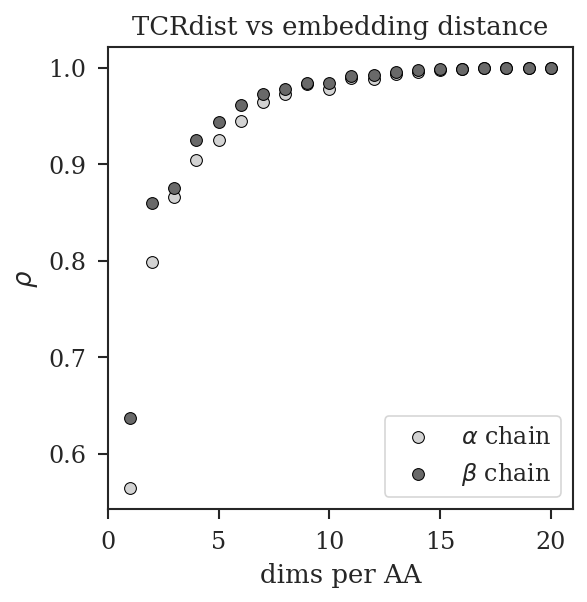

In [113]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

ax.scatter(dims_a, corr_a, s=32, label=r"$\alpha$ chain", color="lightgrey", edgecolors='k', linewidths=.5)
ax.scatter(dims_b, corr_b, s=32, label=r"$\beta$ chain", color="dimgrey",edgecolors='k', linewidths=.5)

ax.set_xlim(0,21)
ax.set_xlabel("dims per AA")
ax.set_ylabel(r"$\rho$")
ax.set_title("TCRdist vs embedding distance")
ax.legend(frameon=True)

fig.savefig("/home/sebastiaan/phd/repositories/sne_manuscript/manuscript_figures/distance_correlation_pearson.png", format="png", dpi=500, bbox_inches="tight")
fig.savefig("/home/sebastiaan/phd/repositories/sne_manuscript/manuscript_figures/distance_correlation_pearson.pdf", format="pdf", dpi=500, bbox_inches="tight")
fig.savefig("/home/sebastiaan/phd/repositories/sne_manuscript/manuscript_figures/distance_correlation_pearson.svg", format="svg", bbox_inches="tight")

Autodetected V gene column: v_call
Autodetected V gene column: v_call


/home/sebastiaan/miniconda3/envs/knn_tcr/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


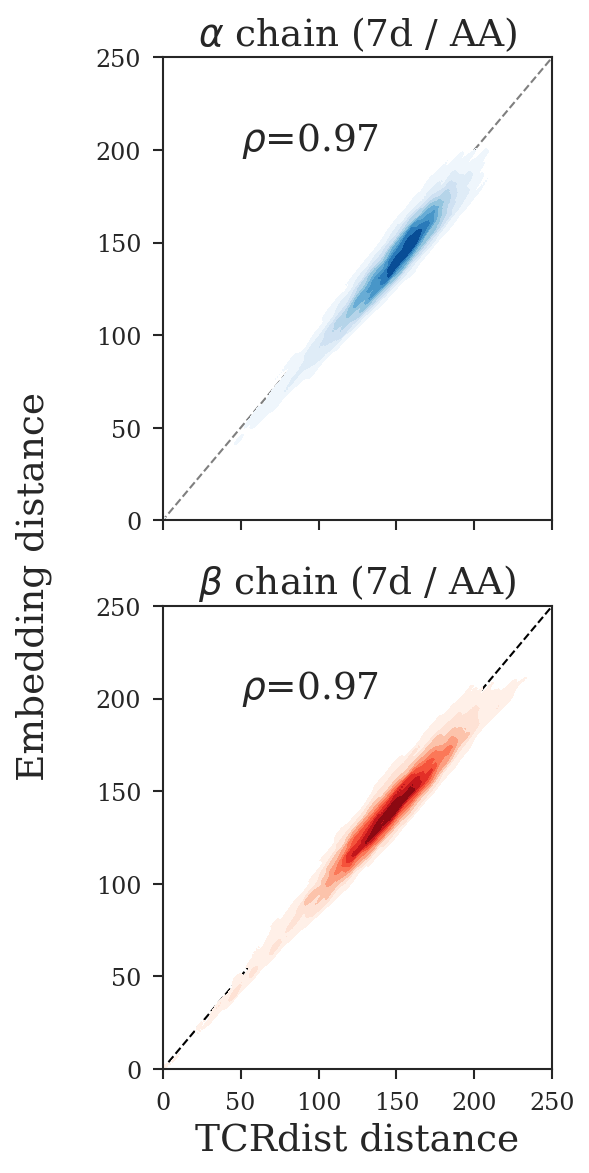

In [55]:
fig, ax = plt.subplots(dpi=150, figsize=(4,8), nrows=2, ncols=1, sharex=True, sharey=True)

dims = 7

alpha_encoder = TCRDistEncoder(aa_dim=dims, chain='a', organism='human', cdr3_col='junction_aa').fit()
beta_encoder = TCRDistEncoder(aa_dim=dims, chain='b', organism='human', cdr3_col='junction_aa').fit()

# alpha chain
vecs = alpha_encoder.transform(pregibon_alpha)
d_vec_a = pdist(X=vecs, metric="euclidean")**2
# beta chain
vecs = beta_encoder.transform(pregibon_beta)
d_vec_b = pdist(X=vecs, metric="euclidean")**2

data = pd.DataFrame({
    'd_td_a': d_td_a,
    'd_vec_a': d_vec_a
})

sns.kdeplot(x='d_td_a', y='d_vec_a', data=data, fill=True, cmap='Blues', bw_adjust=.5, ax=ax[0], alpha=1, linewidths=1, color='black')
# ax[0].scatter(d_td_a, d_vec_a, s=4, c='lightgrey',zorder=0,alpha=.25)
ax[0].set_title(rf"$\alpha$ chain ({dims}d / AA)", fontsize=18)
r = pearsonr(d_td_a, d_vec_a)[0]
text = fr"$\rho$={np.round(r,2)}"
ax[0].text(50,200,text,fontsize=18)
ax[0].plot([-10,260],[-10,260],c="black",ls="--",lw=1,alpha=.5,zorder=0)

data = pd.DataFrame({
    'd_td_b': d_td_b,
    'd_vec_b': d_vec_b
})

sns.kdeplot(x='d_td_b', y='d_vec_b', data=data, fill=True, cmap='Reds', bw_adjust=.5, ax=ax[1], alpha=1)
# ax[1].scatter(d_td_a, d_vec_a, s=4, c='dimgrey',zorder=0,alpha=.25)
ax[1].set_title(rf"$\beta$ chain ({dims}d / AA)", fontsize=18)
r = pearsonr(d_td_b, d_vec_b)[0]
text = fr"$\rho$={np.round(r,2)}"
ax[1].text(50,200,text,fontsize=18)
ax[1].plot([-10,260],[-10,260],c="black",ls="--",lw=1,alpha=1,zorder=0)

ax[0].set_xlim(0,250)
ax[1].set_ylim(0,250)

# ax[0].set_xticklabels()
ax[0].set_ylabel("")
ax[1].set_ylabel("")
ax[0].set_xlabel("")
ax[1].set_xlabel("TCRdist distance",fontsize=18)
fig.supylabel("Embedding distance", fontsize=18)

fig.tight_layout()

fig.savefig("/home/sebastiaan/phd/repositories/sne_manuscript/manuscript_figures/distance_comparison_kde.png", format="png", dpi=500, bbox_inches="tight")
fig.savefig("/home/sebastiaan/phd/repositories/sne_manuscript/manuscript_figures/distance_comparison_kde.pdf", format="pdf", dpi=500, bbox_inches="tight")
fig.savefig("/home/sebastiaan/phd/repositories/sne_manuscript/manuscript_figures/distance_comparison_kde.svg", format="svg", bbox_inches="tight")